# **VGG16 with Preprocessing**

> *Visual Geometry Group (VGG)*

In [1]:
!lscpu

Architecture:             x86_64
  CPU op-mode(s):         32-bit, 64-bit
  Address sizes:          46 bits physical, 48 bits virtual
  Byte Order:             Little Endian
CPU(s):                   4
  On-line CPU(s) list:    0-3
Vendor ID:                GenuineIntel
  Model name:             Intel(R) Xeon(R) CPU @ 2.00GHz
    CPU family:           6
    Model:                85
    Thread(s) per core:   2
    Core(s) per socket:   2
    Socket(s):            1
    Stepping:             3
    BogoMIPS:             4000.28
    Flags:                fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge m
                          ca cmov pat pse36 clflush mmx fxsr sse sse2 ss ht sysc
                          all nx pdpe1gb rdtscp lm constant_tsc rep_good nopl xt
                          opology nonstop_tsc cpuid tsc_known_freq pni pclmulqdq
                           ssse3 fma cx16 pcid sse4_1 sse4_2 x2apic movbe popcnt
                           aes xsave avx f16c rdrand hypervisor 

In [2]:
!nvidia-smi

Sat Feb  8 13:32:16 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P0             25W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## **Importing Libraries**

In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16

## **Image Preprocessing Functions**

In [4]:
def enhance_image(image):
    img = Image.fromarray(image)
    
    brightness = ImageEnhance.Brightness(img)
    img_enhanced = brightness.enhance(1.1)
    
    saturation = ImageEnhance.Color(img_enhanced)
    img_enhanced = saturation.enhance(1.1)
    
    contrast = ImageEnhance.Contrast(img_enhanced)
    img_enhanced = contrast.enhance(1.1)
    
    return np.array(img_enhanced)

In [5]:
def sharpen_image(image):
    laplacian = cv2.Laplacian(image, cv2.CV_64F)
    laplacian_norm = cv2.normalize(laplacian, None, 0, 255, cv2.NORM_MINMAX)
    
    sharpened = cv2.addWeighted(image, 0.8, -laplacian_norm.astype(np.uint8), 0.2, 0)
    img_sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)
    
    return img_sharpened

## **Loading the Dataset**

In [6]:
dataset_path = '/kaggle/input/ichigo/Resized Image'

subfolders = sorted(os.listdir(dataset_path))
print("Subfolders:", subfolders)

Subfolders: ['FreshApple', 'FreshBanana', 'FreshGrape', 'FreshGuava', 'FreshJujube', 'FreshOrange', 'FreshPomegranate', 'FreshStrawberry', 'RottenApple', 'RottenBanana', 'RottenGrape', 'RottenGuava', 'RottenJujube', 'RottenOrange', 'RottenPomegranate', 'RottenStrawberry']


In [7]:
images = []
labels = []

for label, folder in enumerate(subfolders):
    folder_path = os.path.join(dataset_path, folder)

    for img_file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_file)
        img = cv2.imread(img_path)

        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_processed = enhance_image(img)
            img_processed = sharpen_image(img_processed)
            
            images.append(img_processed)
            labels.append(label)
        else:
            print(f"Failed to load image: {img_path}")

images = np.array(images)
labels = np.array(labels)

In [8]:
print("Original shape of the images: ", images.shape)
print("Original shape of the labels: ", labels.shape)

Original shape of the images:  (3200, 256, 256, 3)
Original shape of the labels:  (3200,)


In [9]:
images = images.astype('float32') / 255.0

X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

In [10]:
print("Shape of X train:", X_train.shape)
print("Shape of X test :", X_test.shape, '\n')

print("Shape of y train:", y_train.shape)
print("Shape of y test :", y_test.shape)

Shape of X train: (2560, 256, 256, 3)
Shape of X test : (640, 256, 256, 3) 

Shape of y train: (2560,)
Shape of y test : (640,)


## **Model Training**

In [11]:
input_shape = X_train.shape[1:]
num_classes = len(subfolders)

vgg16_base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
vgg16_base_model.trainable = False

model = models.Sequential([
    layers.Rescaling(scale=255.0),
    layers.Lambda(tf.keras.applications.vgg16.preprocess_input),
    vgg16_base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
vgg16_base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 256, 256, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 256, 256, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 128, 128, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 128, 128, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 128, 128, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 64, 64, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 64, 64, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 64, 64, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 64, 64, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 32, 32, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 32, 32, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 32, 32, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 32, 32, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 16, 16, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 8, 8, 512)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda (Lambda)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ vgg16 (Functional)                   │ (None, 8, 8, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ ?                           │     0 (unbuilt) │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [14]:
history = model.fit(X_train, y_train,
                    epochs=10, batch_size=32,
                    validation_split=0.2)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 22s 133ms/step - accuracy: 0.3474 - loss: 4.5965 - val_accuracy: 0.9102 - val_loss: 0.3001
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.8196 - loss: 0.5595 - val_accuracy: 0.9492 - val_loss: 0.1893
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.8885 - loss: 0.3881 - val_accuracy: 0.9590 - val_loss: 0.1297
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.9295 - loss: 0.2198 - val_accuracy: 0.9688 - val_loss: 0.0980
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.9441 - loss: 0.1974 - val_accuracy: 0.9785 - val_loss: 0.0853
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.9628 - loss: 0.1226 - val_accuracy: 0.9746 - val_loss: 0.0816
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.9642 - loss: 0.0977 - val_accuracy: 0.9824 - val_loss: 0.0629
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.9612 - loss: 0.1078 - val_accuracy: 0

## **Model Testing**

In [15]:
y_pred_probs = model.predict(X_test)
y_pred_vgg16 = np.argmax(y_pred_probs, axis=1)

accuracy_vgg16 = accuracy_score(y_test, y_pred_vgg16)
print(f"VGG16 Accuracy: {accuracy_vgg16:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step
VGG16 Accuracy: 0.9781


In [16]:
average_precision = precision_score(y_test, y_pred_vgg16, average='macro')
average_recall = recall_score(y_test, y_pred_vgg16, average='macro')
average_f1 = f1_score(y_test, y_pred_vgg16, average='macro')

print(f"Average Precision: {average_precision:.4f}")
print(f"Average Recall: {average_recall:.4f}")
print(f"Average F1-Score: {average_f1:.4f}")

Average Precision: 0.9769
Average Recall: 0.9768
Average F1-Score: 0.9765


In [17]:
print("VGG16 Classification Report:\n")
print(classification_report(y_test, y_pred_vgg16, target_names=subfolders))

VGG16 Classification Report:

                   precision    recall  f1-score   support

       FreshApple       1.00      0.98      0.99        54
      FreshBanana       1.00      1.00      1.00        43
       FreshGrape       0.97      1.00      0.98        56
       FreshGuava       1.00      1.00      1.00        35
      FreshJujube       0.97      1.00      0.99        33
      FreshOrange       1.00      0.97      0.99        36
 FreshPomegranate       0.97      0.95      0.96        38
  FreshStrawberry       1.00      1.00      1.00        48
      RottenApple       0.95      0.98      0.96        41
     RottenBanana       1.00      1.00      1.00        40
      RottenGrape       1.00      0.95      0.98        44
      RottenGuava       0.97      0.97      0.97        39
     RottenJujube       0.97      0.88      0.92        32
     RottenOrange       0.91      1.00      0.95        31
RottenPomegranate       0.95      0.95      0.95        39
 RottenStrawberry       0

## **Visualisation**

### **Training and Validation Accuracy**

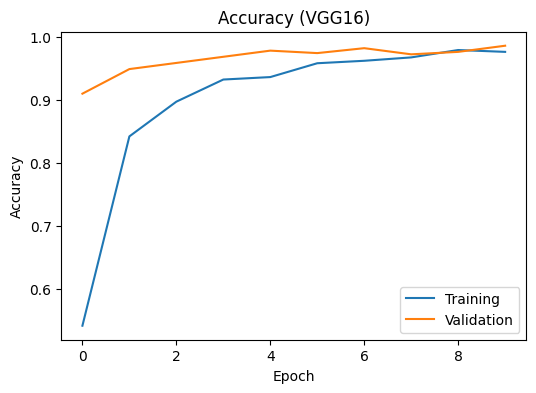

In [18]:
plt.figure(figsize=(6, 4))

plt.title('Accuracy (VGG16)')
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.show()

### **Training and Validation Loss**

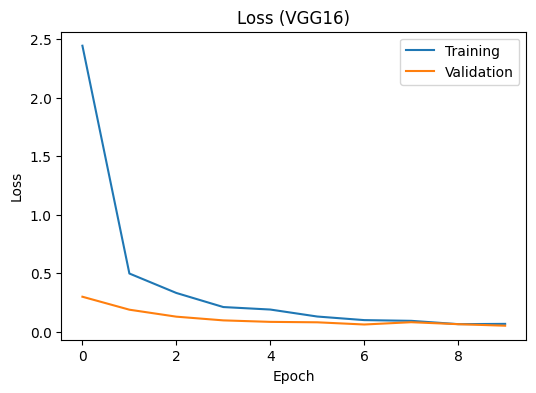

In [19]:
plt.figure(figsize=(6, 4))

plt.title('Loss (VGG16)')
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.show()

### **Confusion Matrix**

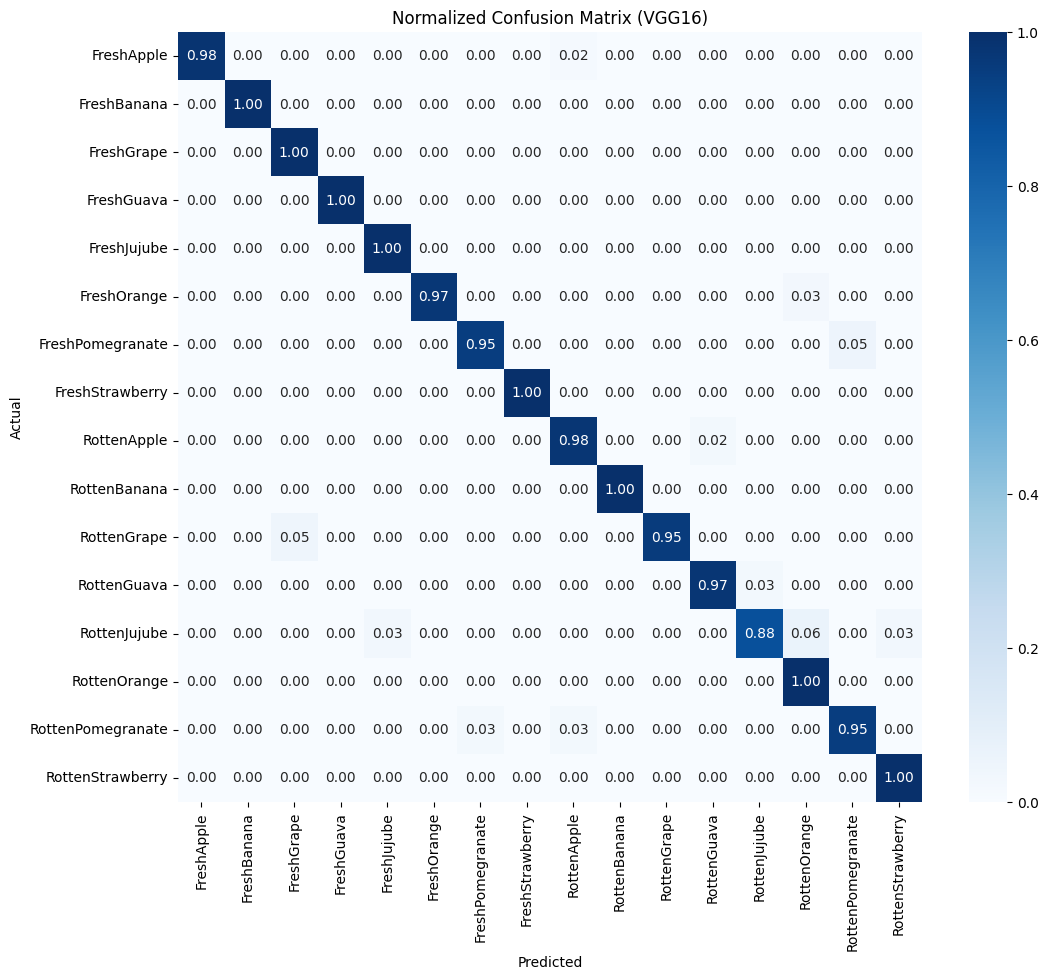

In [20]:
conf_matrix_vgg16 = confusion_matrix(y_test, y_pred_vgg16)

conf_matrix_vgg16_normalised = conf_matrix_vgg16.astype('float') / conf_matrix_vgg16.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix_vgg16_normalised, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=subfolders, yticklabels=subfolders)
plt.title('Normalized Confusion Matrix (VGG16)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### **Class-wise Precision, Recall, and F1-Score**

In [21]:
precision = precision_score(y_test, y_pred_vgg16, average=None)
recall = recall_score(y_test, y_pred_vgg16, average=None)
f1 = f1_score(y_test, y_pred_vgg16, average=None)

class_metrics = pd.DataFrame({
    'Class': subfolders,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
})

print("Class-wise Precision, Recall, and F1-Score (VGG16):\n")
print(class_metrics)

Class-wise Precision, Recall, and F1-Score (VGG16):

                Class  Precision    Recall  F1-Score
0          FreshApple   1.000000  0.981481  0.990654
1         FreshBanana   1.000000  1.000000  1.000000
2          FreshGrape   0.965517  1.000000  0.982456
3          FreshGuava   1.000000  1.000000  1.000000
4         FreshJujube   0.970588  1.000000  0.985075
5         FreshOrange   1.000000  0.972222  0.985915
6    FreshPomegranate   0.972973  0.947368  0.960000
7     FreshStrawberry   1.000000  1.000000  1.000000
8         RottenApple   0.952381  0.975610  0.963855
9        RottenBanana   1.000000  1.000000  1.000000
10        RottenGrape   1.000000  0.954545  0.976744
11        RottenGuava   0.974359  0.974359  0.974359
12       RottenJujube   0.965517  0.875000  0.918033
13       RottenOrange   0.911765  1.000000  0.953846
14  RottenPomegranate   0.948718  0.948718  0.948718
15   RottenStrawberry   0.968750  1.000000  0.984127


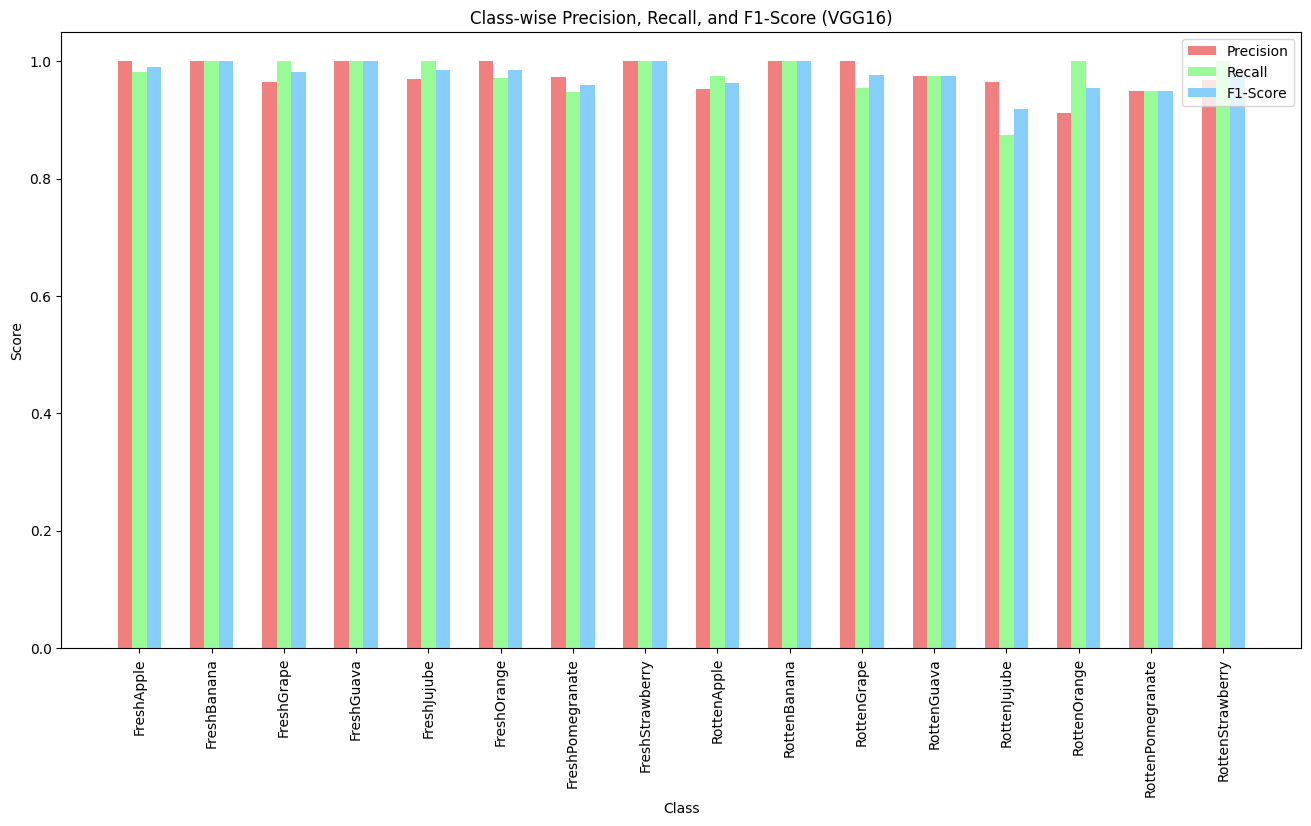

In [22]:
plt.figure(figsize=(16, 8))
x = np.arange(len(subfolders))
width = 0.2

plt.bar(x - width, precision, width, label='Precision', color='lightcoral')
plt.bar(x, recall, width, label='Recall', color='palegreen')
plt.bar(x + width, f1, width, label='F1-Score', color='lightskyblue')

plt.title('Class-wise Precision, Recall, and F1-Score (VGG16)')
plt.xlabel('Class')
plt.ylabel('Score')
plt.xticks(x, subfolders, rotation=90)
plt.legend()
plt.show()

## **Exporting Model**

In [23]:
model.save('/kaggle/working/VGG16_WithPreprocessing.h5')